In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
from tqdm.auto import tqdm
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import odds_datasets

from balif import Balif
from sklearn.metrics import average_precision_score

  0%|          | 0/18 [00:00<?, ?it/s]

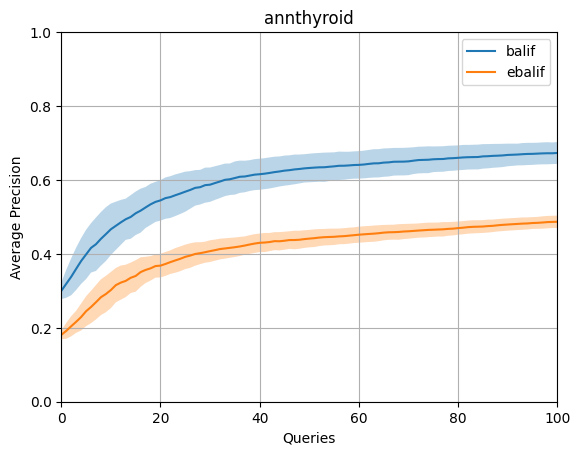

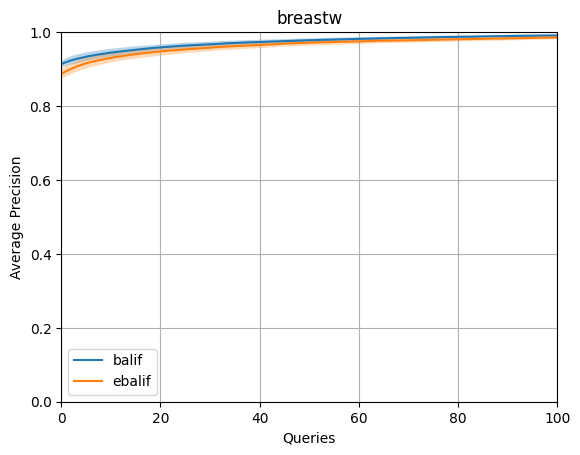

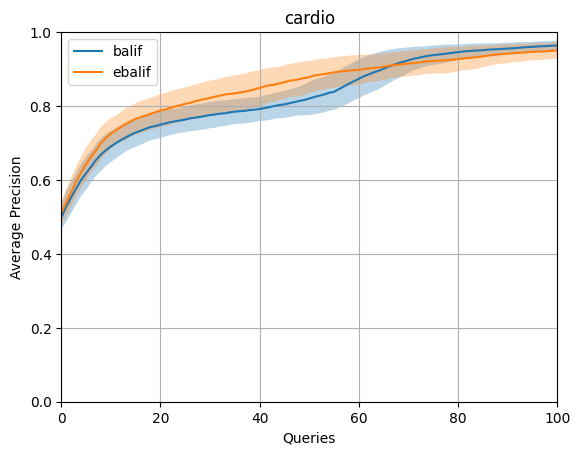

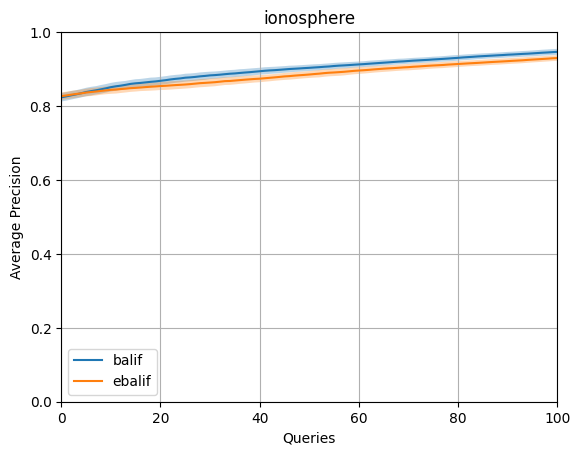

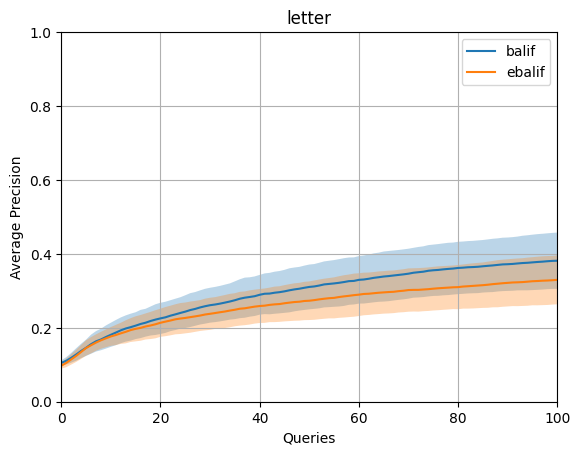

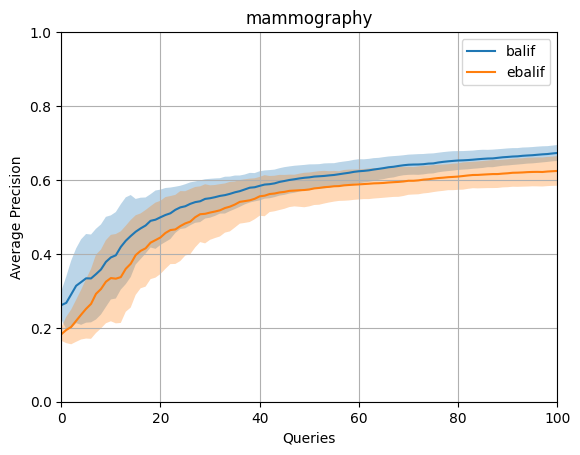

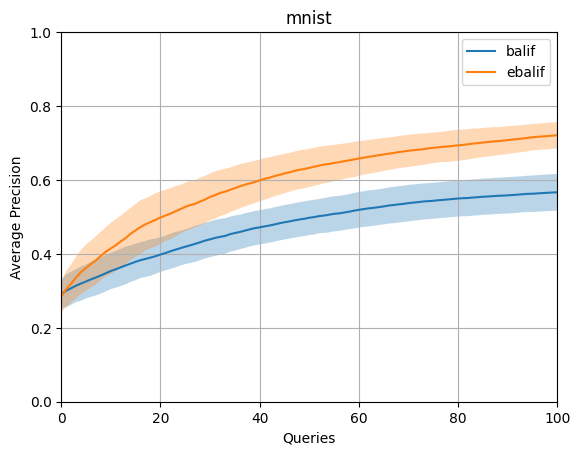

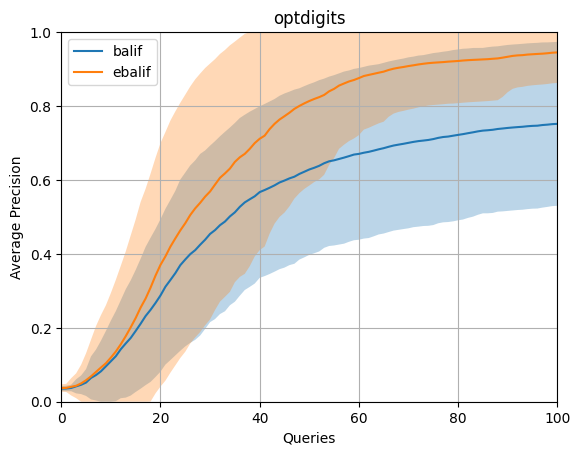

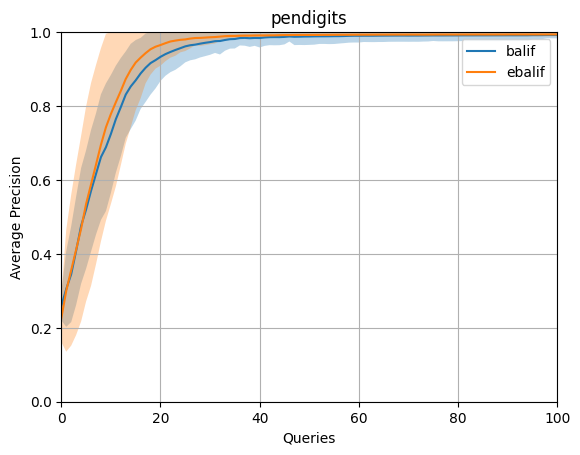

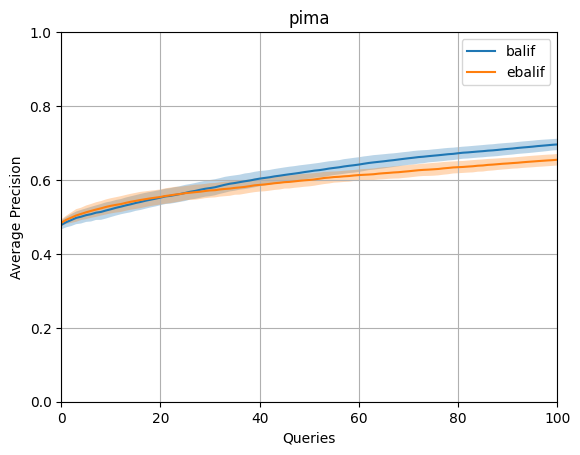

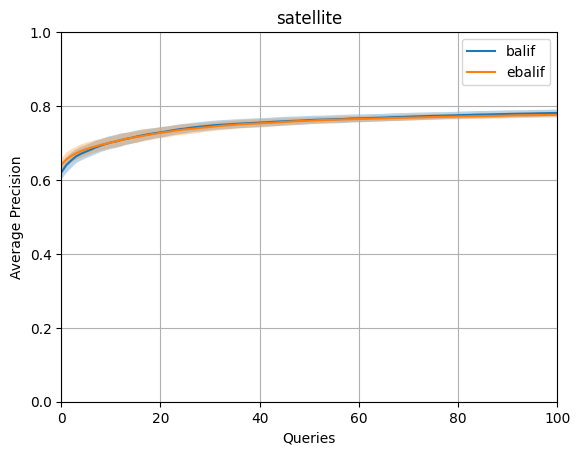

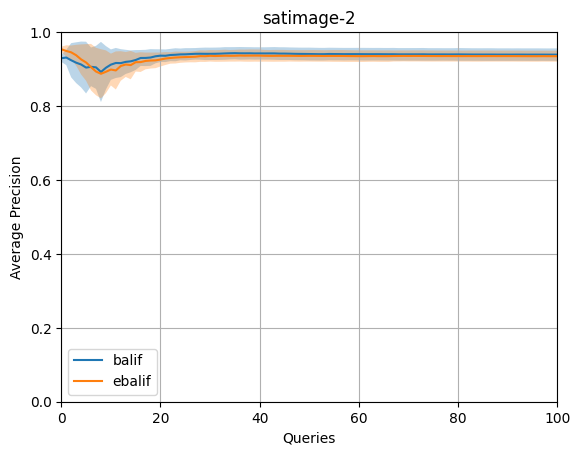

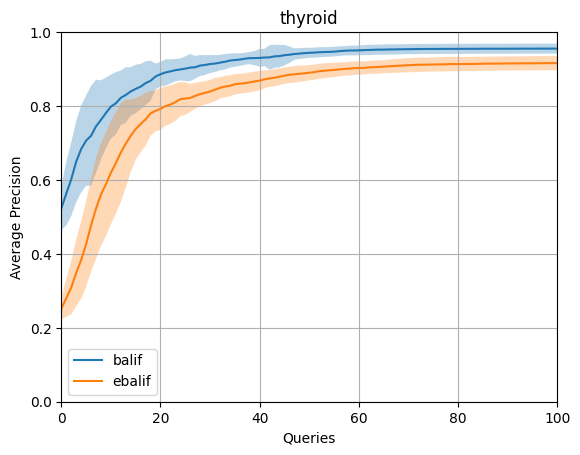

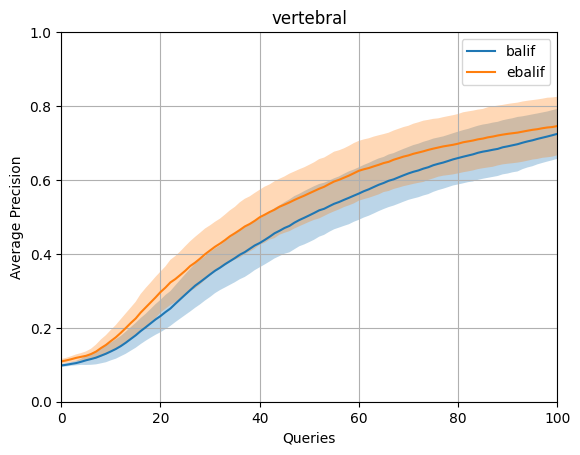

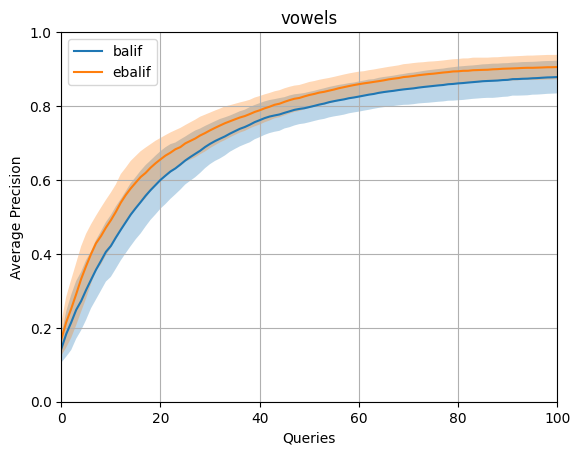

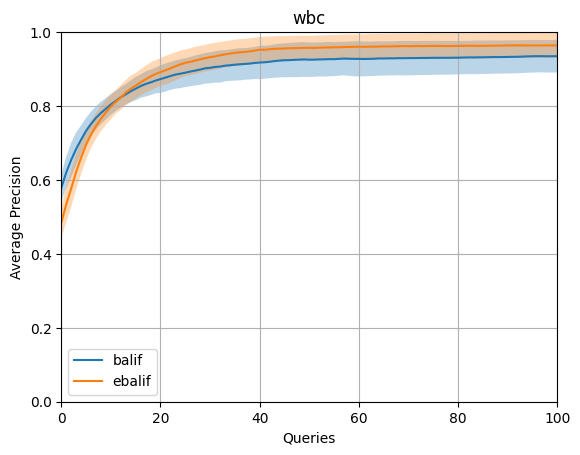

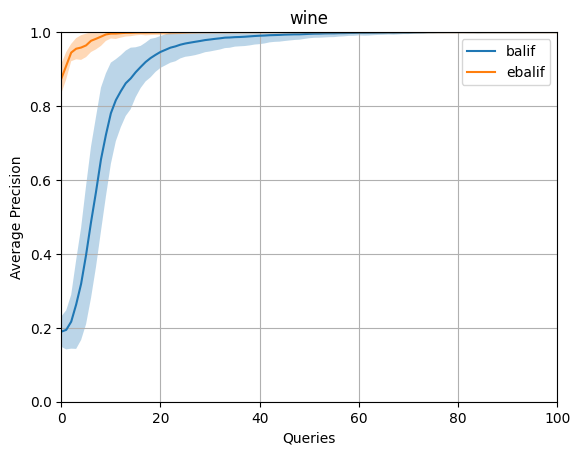

In [6]:
for dataset_name in tqdm(sorted(odds_datasets.datasets_names)):
    if dataset_name in ["cover"]: # cover is so large it causes OOM
        continue
    
    for model_name in ["balif", "ebalif"]:
        ap = jnp.load(f"results/{dataset_name}_{model_name}.npy", allow_pickle=True)
        ap_mean, ap_std = ap.mean(axis=0), ap.std(axis=0)
        plt.plot(ap.mean(axis=0), label=model_name)
        plt.fill_between(
            range(len(ap_mean)),
            jnp.maximum(0, ap_mean - ap_std),
            jnp.minimum(1, ap_mean + ap_std),
            alpha=0.3,
        )

    plt.title(dataset_name)
    plt.legend()
    plt.xlabel("Queries")
    plt.ylabel("Average Precision")
    plt.ylim(0.0, 1.0)
    plt.xlim(0, 100)
    plt.grid()
    plt.savefig(f"figures/average_precision_evolution_{dataset_name}.pdf", bbox_inches="tight")
    plt.show()